# LangGraph Router with Video Analysis Workflow

This notebook extends the simple symptom specialist router to handle 4 scenarios:
1. instructions_specialist: answers how to use the assistant.
2. patient_search: looks up a patient in the local synthetic database.
3. video_analysis_flow: runs the `video_pipeline` module to extract expression, pose, and transcript.
4. symptom_flow: evaluates the patient using a structured symptom specialist, taking into account video artifacts.


In [2]:
from __future__ import annotations
from collections.abc import Callable, Mapping, Sequence
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Literal, cast
import json
import os
import uuid
from dotenv import load_dotenv
from IPython.display import Image, Markdown, display
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import BaseTool, tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from pydantic import BaseModel, Field, SecretStr, field_validator
from video_pipeline.orchestrator import process_video
from video_pipeline.contracts import VideoAnalysisResult, PipelineConfig


In [3]:
ChatBackendKind = Literal["openai", "openrouter", "openai_compatible"]
Destination = Literal["instructions_specialist", "patient_search", "video_analysis_flow", "video_qa_flow"]

@dataclass(frozen=True)
class NotebookChatSettings:
    """Configuration for a chat-model-backed notebook runtime."""
    backend: ChatBackendKind
    model: str
    base_url: str | None
    api_key: str | None
    temperature: float

@dataclass(frozen=True)
class NotebookRuntimeSettings:
    """Top-level runtime settings used by the notebook graph."""
    control_model: NotebookChatSettings

def _load_env_file(env_path: Path | None = None) -> Path:
    """Load the notebook `.env` file and return its resolved path."""
    resolved_env_path = env_path or Path.cwd() / ".env"
    if not resolved_env_path.exists():
        raise FileNotFoundError(f"Could not find .env file at {resolved_env_path}")
    load_dotenv(resolved_env_path, override=True)
    return resolved_env_path

def _read_chat_backend(value: str) -> ChatBackendKind:
    """Validate a chat backend value."""
    normalized_value = value.strip().lower()
    if normalized_value not in {"openai", "openrouter", "openai_compatible"}:
        raise ValueError(
            "Chat backend must be 'openai', 'openrouter', or 'openai_compatible'."
        )
    return cast(ChatBackendKind, normalized_value)

def _read_float_env(name: str, default: float) -> float:
    raw_value = os.getenv(name)
    if raw_value is None or not raw_value.strip():
        return default
    return float(raw_value)

def load_notebook_runtime_settings(env_path: Path | None = None) -> NotebookRuntimeSettings:
    _load_env_file(env_path)
    control_model_name = os.getenv("SCREENING_AGENT_CONTROL_MODEL", "").strip()
    if not control_model_name:
        raise ValueError("SCREENING_AGENT_CONTROL_MODEL must be set in the .env file.")
    control_settings = NotebookChatSettings(
        backend=_read_chat_backend(
            os.getenv("SCREENING_AGENT_CONTROL_BACKEND", "openai_compatible")
        ),
        model=control_model_name,
        base_url=os.getenv("SCREENING_AGENT_CONTROL_BASE_URL"),
        api_key=os.getenv("SCREENING_AGENT_CONTROL_API_KEY"),
        temperature=_read_float_env("SCREENING_AGENT_CONTROL_TEMPERATURE", 0.0),
    )
    return NotebookRuntimeSettings(control_model=control_settings)

def build_chat_model(settings: NotebookChatSettings) -> BaseChatModel:
    if settings.backend == "openrouter":
        from langchain_openrouter import ChatOpenRouter
        return ChatOpenRouter(
            model=settings.model,
            api_key=SecretStr(settings.api_key) if settings.api_key else None,
            temperature=settings.temperature,
        )
    model_kwargs: dict[str, Any] = {
        "model": settings.model,
        "temperature": settings.temperature,
    }
    if settings.api_key:
        model_kwargs["api_key"] = SecretStr(settings.api_key)
    if settings.backend == "openai_compatible":
        if not settings.base_url:
            raise ValueError(
                "SCREENING_AGENT_CONTROL_BASE_URL must be set when using the openai_compatible backend."
            )
        model_kwargs["base_url"] = settings.base_url
    return ChatOpenAI(**model_kwargs)

In [4]:
@dataclass(frozen=True)
class SyntheticPatientCase:
    """Synthetic patient details used to simulate an active notebook context."""
    key: str
    display_name: str
    age_description: str
    background: str
    chronic_conditions: tuple[str, ...]
    medications: tuple[str, ...]
    allergies: tuple[str, ...]
    current_context: str

SYNTHETIC_PATIENT_CASES: dict[str, SyntheticPatientCase] = {
    "maria_teacher": SyntheticPatientCase(
        key="maria_teacher",
        display_name="Maria S.",
        age_description="34-year-old school teacher",
        background="Lives with two children and works in a crowded classroom.",
        chronic_conditions=("mild intermittent asthma",),
        medications=("albuterol inhaler as needed",),
        allergies=("penicillin",),
        current_context="Reports that several students at school have had fever and sore throat this week.",
    ),
    "joao_retired_driver": SyntheticPatientCase(
        key="joao_retired_driver",
        display_name="João P.",
        age_description="67-year-old retired bus driver",
        background="Lives with his spouse and recently attended a large family gathering.",
        chronic_conditions=("type 2 diabetes", "hypertension", "hyperlipidemia"),
        medications=("metformin", "losartan", "atorvastatin"),
        allergies=("no known drug allergies",),
        current_context="Mentions reduced appetite and mild fatigue after a weekend with many relatives indoors.",
    ),
    "ana_grad_student": SyntheticPatientCase(
        key="ana_grad_student",
        display_name="Ana C.",
        age_description="26-year-old graduate student",
        background="Recently returned from a short domestic trip and has been sleeping poorly.",
        chronic_conditions=("migraine", "iron deficiency"),
        medications=("sumatriptan as needed", "ferrous sulfate"),
        allergies=("shellfish",),
        current_context="Says that stress has been high for the last two weeks because of exams and travel.",
    ),
}

def get_patient_case(case_key: str) -> SyntheticPatientCase:
    """Return one synthetic patient case by key."""
    if case_key not in SYNTHETIC_PATIENT_CASES:
        available_keys = ", ".join(sorted(SYNTHETIC_PATIENT_CASES))
        raise KeyError(f"Unknown patient case {case_key!r}. Available cases: {available_keys}")
    return SYNTHETIC_PATIENT_CASES[case_key]

def render_active_patient_context(patient_case: SyntheticPatientCase) -> str:
    """Render the synthetic patient into a compact clinical context block."""
    chronic_conditions = ", ".join(patient_case.chronic_conditions)
    medications = ", ".join(patient_case.medications)
    allergies = ", ".join(patient_case.allergies)
    return (
        f"Patient: {patient_case.display_name}\n"
        f"Profile: {patient_case.age_description}\n"
        f"Background: {patient_case.background}\n"
        f"Chronic conditions: {chronic_conditions}\n"
        f"Current medications: {medications}\n"
        f"Allergies: {allergies}\n"
        f"Current context: {patient_case.current_context}"
    )

In [5]:
VIDEO_QA_SYSTEM_PROMPT = """
You are a clinical video analysis assistant.

Analyze the processed video using the available `VideoAnalysisResult` and patient context.

`VideoAnalysisResult` may include:

* video metadata
* facial-expression windows
* posture and gesture windows
* timestamped transcription

Your primary task is to perform an integrated multimodal analysis. Do not interpret speech, facial expression, posture, or patient context in isolation.

Correlate:

* what the patient says
* facial expressions shown while speaking
* gestures and postures occurring at the same time
* changes across the video timeline
* known symptoms, diagnoses, medications, psychological state, history, and other patient context

Use timestamps whenever possible to determine whether visual and verbal signals reinforce, contradict, or clarify each other.

Assess whether observed patterns may:

* relate to a reported disease, symptom, pain, medication effect, or psychological condition
* suggest discomfort, distress, anxiety, sadness, fatigue, confusion, hesitation, reduced engagement, or another relevant state
* reveal a health or well-being concern that a healthcare professional should examine more closely

Prioritize clinically useful synthesis over listing raw detections. Explain why a combination of signals may be relevant. For example, repeated touching of the head, neck, or chest is more meaningful when it occurs while the patient reports pain or related symptoms.

When relevant, report:

* the overall observed affect and behavior
* important moments and temporal changes
* agreement or inconsistency between speech and nonverbal behavior
* possible clinical relevance
* issues that may deserve professional attention
* useful follow-up questions
* limitations of the analysis

Ground every conclusion in the provided data. Do not invent observations.

Do not diagnose or imply certainty from video analysis alone. Use cautious language such as “may suggest”, “could be related to”, “appears consistent with”, or “may warrant further assessment”.

If the analysis result is missing, state that the video has not been processed. If patient context is unavailable, state that conclusions are limited to the video. If one modality is missing, continue with the available data and mention the limitation.
""".strip()

def extract_json_object(text: str) -> str:
    """Extract the first JSON object found in a text response."""
    start_index = text.find("{")
    end_index = text.rfind("}")
    if start_index == -1 or end_index == -1 or end_index < start_index:
        raise ValueError("The model response did not contain a JSON object.")
    return text[start_index : end_index + 1]

In [6]:
ROUTER_SYSTEM_PROMPT = """
You are a routing assistant for a clinical screening demo.
Choose exactly one destination.
Route to `instructions_specialist` when the user asks how to use the assistant, what details to provide, or how to phrase a request.
Route to `patient_search` when the user wants to load a patient profile, search for a patient by name, or look up patient details.
Route to `video_analysis_flow` when the user asks to analyze a video, process a video file, load a video, or run the video processing pipeline.
Route to `video_qa_flow` when the user asks questions about the video content, asks to analyze the patient profile and video data, or asks about expressions, posture, speech, or transcription details from the loaded video.
Return the most appropriate destination for the current question.
""".strip()

INSTRUCTIONS_SPECIALIST_PROMPT = """
You are the control model for a clinical screening notebook demo.
Explain how the user can ask a better question.
Suggest the most useful details to include, such as age range, timeline, severity, triggers, associated symptoms, and relevant medical history.
Keep the answer concise, practical, and patient-friendly.
""".strip()

class NotebookState(MessagesState):
    """Graph state for the message-first notebook workflow."""
    active_patient_key: str
    active_patient_display_name: str
    active_patient_context: str
    route: Destination | None
    router_rationale: str | None
    video_path: str | None
    video_analysis_result: VideoAnalysisResult | None

class RouteDecision(BaseModel):
    """Structured router decision with two valid destinations."""
    destination: Destination = Field(
        description="The branch that should continue the user request."
    )
    rationale: str = Field(description="A short explanation for the routing choice.")

def get_latest_human_message(messages: Sequence[BaseMessage]) -> HumanMessage:
    """Return the newest human message from a message sequence."""
    for message in reversed(messages):
        if isinstance(message, HumanMessage):
            return message
    raise ValueError("The graph expected at least one human message in state.")

def get_latest_human_message_text(messages: Sequence[BaseMessage]) -> str:
    """Return the text content of the newest human message."""
    return get_latest_human_message(messages).text

def get_last_final_ai_message(messages: Sequence[BaseMessage]) -> AIMessage | None:
    """Return the newest AI message that is not a tool-call planner message."""
    for message in reversed(messages):
        if isinstance(message, AIMessage) and not message.tool_calls:
            return message
    return None

In [7]:
def invoke_router_fallback(llm: BaseChatModel, question: str) -> RouteDecision:
    """Run a JSON-prompt fallback when native structured output is unavailable."""
    fallback_system_prompt = f"""{ROUTER_SYSTEM_PROMPT}\nReturn only a JSON object with this schema:\n{{\n  \"destination\": \"instructions_specialist\" | \"patient_search\" | \"video_analysis_flow\" | \"video_qa_flow\",\n  \"rationale\": \"short explanation\"\n}}\n""".strip()
    response = llm.invoke(
        [
            SystemMessage(content=fallback_system_prompt),
            HumanMessage(content=question),
        ]
    )
    if response.text in {"instructions_specialist", "patient_search", "video_analysis_flow", "video_qa_flow"}:
        return RouteDecision(
            destination=cast(Destination, response.text),
            rationale="Fallback plain-text route",
        )
    return RouteDecision.model_validate_json(extract_json_object(response.text))

def build_router_node(
    llm: BaseChatModel,
) -> Callable[[NotebookState], dict[str, Destination | str]]:
    """Create a router node that writes the chosen destination to state."""
    structured_router = llm.with_structured_output(RouteDecision)
    def router_node(state: NotebookState) -> dict[str, Destination | str]:
        question = get_latest_human_message_text(state["messages"])
        router_messages = [
            SystemMessage(content=ROUTER_SYSTEM_PROMPT),
            HumanMessage(content=question),
        ]
        try:
            decision = RouteDecision.model_validate(
                structured_router.invoke(router_messages)
            )
        except Exception:
            decision = invoke_router_fallback(llm, question)
        print(f"Router response: {decision}")
        return {
            "route": decision.destination,
            "router_rationale": decision.rationale,
        }
    return router_node

def build_instructions_node(
    control_llm: BaseChatModel,
) -> Callable[[NotebookState], dict[str, list[BaseMessage]]]:
    """Create the instructions branch node rendered by the control model."""
    def instructions_node(state: NotebookState) -> dict[str, list[BaseMessage]]:
        question = get_latest_human_message_text(state["messages"])
        response = control_llm.invoke(
            [
                SystemMessage(content=INSTRUCTIONS_SPECIALIST_PROMPT),
                HumanMessage(content=question),
            ]
        )
        return {"messages": [response]}
    return instructions_node

def build_video_qa_node(
    control_llm: BaseChatModel,
) -> Callable[[NotebookState], dict[str, list[BaseMessage]]]:
    """Create the video metadata QA node rendered by the control model."""
    def video_qa_node(state: NotebookState) -> dict[str, list[BaseMessage]]:
        question = get_latest_human_message_text(state["messages"])
        result = state.get("video_analysis_result")
        if result:
            result_str = json.dumps(result.model_dump(), ensure_ascii=False, indent=2)
        else:
            result_str = "No video analysis result is currently loaded."
        patient_context = state.get("active_patient_context", "No active patient context loaded.")
        response = control_llm.invoke(
            [
                SystemMessage(content=VIDEO_QA_SYSTEM_PROMPT),
                HumanMessage(
                    content=(
                        f"User question: {question}\n\n"
                        f"Active patient context:\n{patient_context}\n\n"
                        f"Video analysis metadata:\n{result_str}"
                    )
                ),
            ]
        )
        return {"messages": [response]}
    return video_qa_node

In [8]:
def build_patient_search_node(
    control_llm: BaseChatModel,
) -> Callable[[NotebookState], dict[str, Any]]:
    """Node that simulates a patient search and updates the active context."""
    
    def patient_search_node(state: NotebookState) -> dict[str, Any]:
        question = get_latest_human_message_text(state["messages"])
        
        # Simple heuristic: we just try to find a key from SYNTHETIC_PATIENT_CASES in the message
        # In a real scenario, we'd use the LLM to extract the name and query a DB.
        found_key = None
        for key, patient in SYNTHETIC_PATIENT_CASES.items():
            if patient.display_name.split()[0].lower() in question.lower() or key in question.lower():
                found_key = key
                break
                
        if not found_key:
            # Default to the first one if not found just for demo purposes
            found_key = list(SYNTHETIC_PATIENT_CASES.keys())[0]
            
        patient_case = get_patient_case(found_key)
        context = render_active_patient_context(patient_case)
        
        response = AIMessage(content=f"Loaded patient profile for {patient_case.display_name}.")
        return {
            "messages": [response],
            "active_patient_key": found_key,
            "active_patient_display_name": patient_case.display_name,
            "active_patient_context": context,
        }
        
    return patient_search_node


def format_video_analysis_summary(result: VideoAnalysisResult) -> str:
    """Format the video analysis result into a concise summary."""
    lines = ["Video Analysis Summary:"]
    lines.append(f"- Duration: {result.duration_s:.1f}s")
    
    if result.transcription:
        transcript_segments = [s for s in result.transcription.segments if s.text.strip()]
        if transcript_segments:
            lines.append("- Transcript:")
            for s in transcript_segments:
                lines.append(f"  [{s.start_s:.1f}s - {s.end_s:.1f}s] {s.text}")
        elif result.transcription.text.strip():
            lines.append("- Transcript:")
            lines.append(f"  {result.transcription.text.strip()}")
                
    if result.expression and result.expression.windows:
        lines.append("- Dominant Expressions:")
        for w in result.expression.windows:
            if w.dominant:
                lines.append(f"  [{w.start_s:.1f}s - {w.end_s:.1f}s] {w.dominant.label} (score: {w.dominant.score:.2f})")
                
    if result.pose and result.pose.windows:
        lines.append("- Posture Observations:")
        for w in result.pose.windows:
            if w.dominant:
                lines.append(f"  [{w.start_s:.1f}s - {w.end_s:.1f}s] {w.dominant.label} (score: {w.dominant.score:.2f})")
                
    return "\n".join(lines)


def build_video_analysis_node(
    control_llm: BaseChatModel,
) -> Callable[[NotebookState], dict[str, Any]]:
    """Node that processes a video and generates a summary."""
    
    def video_analysis_node(state: NotebookState) -> dict[str, Any]:
        video_path = state.get("video_path")
        if not video_path:
            response = AIMessage(content="No video path was provided in the state for analysis.")
            return {"messages": [response]}
            
        try:
            # Process video using the pipeline
            analysis_result = process_video(video_path, config=PipelineConfig(debug=False))
            summary_text = format_video_analysis_summary(analysis_result)
            
            # Update the active patient context with this new evidence
            current_context = state.get("active_patient_context", "")
            new_context = current_context + "\n\n" + summary_text
            
            response = AIMessage(content=f"Video analysis complete.\n\n{summary_text}")
            
            return {
                "messages": [response],
                "video_analysis_result": analysis_result,
                "active_patient_context": new_context
            }
        except Exception as e:
            response = AIMessage(content=f"Failed to analyze video: {str(e)}")
            return {"messages": [response]}
            
    return video_analysis_node



In [9]:
def route_from_router(state: NotebookState) -> Destination:
    """Return the next node name based on the router output."""
    route = state.get("route")
    if route is None:
        raise ValueError("The router must set `route` before conditional routing runs.")
    return cast(Destination, route)

def build_router_demo_graph_v3(
    *,
    control_llm: BaseChatModel,
) -> Any:
    """Build and compile the router graph with the video QA workflow."""
    builder: Any = StateGraph(NotebookState)
    builder.add_node("router", build_router_node(control_llm))
    builder.add_node("instructions_specialist", build_instructions_node(control_llm))
    builder.add_node("patient_search", build_patient_search_node(control_llm))
    builder.add_node("video_analysis_flow", build_video_analysis_node(control_llm))
    builder.add_node("video_qa_flow", build_video_qa_node(control_llm))
    
    builder.add_edge(START, "router")
    builder.add_conditional_edges(
        "router",
        route_from_router,
        {
            "video_qa_flow": "video_qa_flow",
            "instructions_specialist": "instructions_specialist",
            "patient_search": "patient_search",
            "video_analysis_flow": "video_analysis_flow",
        },
    )
    builder.add_edge("video_qa_flow", END)
    builder.add_edge("instructions_specialist", END)
    builder.add_edge("patient_search", END)
    builder.add_edge("video_analysis_flow", END)
    return builder.compile()

def show_graph_structure(compiled_graph: Any) -> None:
    """Render a Mermaid diagram for the compiled graph."""
    try:
        display(Image(compiled_graph.get_graph().draw_mermaid_png()))
    except Exception:
        mermaid = compiled_graph.get_graph().draw_mermaid()
        display(Markdown(f"```mermaid\n{mermaid}\n```"))

def create_initial_state(question: str, active_patient_key: str) -> NotebookState:
    """Create the initial graph state for one notebook question."""
    patient_case = get_patient_case(active_patient_key)
    return {
        "messages": [HumanMessage(content=question)],
        "active_patient_key": active_patient_key,
        "active_patient_display_name": patient_case.display_name,
        "active_patient_context": render_active_patient_context(patient_case),
        "route": None,
        "router_rationale": None,
        "video_path": None,
        "video_analysis_result": None,
    }

def describe_run_result(result: NotebookState) -> dict[str, Any]:
    """Build a compact notebook summary for one graph run."""
    final_message = get_last_final_ai_message(result["messages"])
    return {
        "active_patient": result["active_patient_display_name"],
        "route": result["route"],
        "router_rationale": result["router_rationale"],
        "video_analysis_summary": "Present" if result.get("video_analysis_result") else None,
        "final_answer": final_message.text if final_message is not None else None,
    }

## Demo wiring

The next cells:

- load the same environment variables used by the current project setup;
- build the shared control model and the structured symptom specialist runtime;
- choose one synthetic patient as the active context;
- compile the message-first v3 graph.

In [10]:
runtime_settings = load_notebook_runtime_settings()
control_llm = build_chat_model(runtime_settings.control_model)
demo_graph_v3 = build_router_demo_graph_v3(
    control_llm=control_llm,
)
ACTIVE_PATIENT_KEY = "maria_teacher"
ACTIVE_PATIENT = get_patient_case(ACTIVE_PATIENT_KEY)
{
    "control_backend": runtime_settings.control_model.backend,
    "control_model": runtime_settings.control_model.model,
    "active_patient": ACTIVE_PATIENT.display_name,
    "available_patients": sorted(SYNTHETIC_PATIENT_CASES),
}

{'control_backend': 'openai_compatible',
 'control_model': 'openai/gpt-oss-20b:free',
 'active_patient': 'Maria S.',
 'available_patients': ['ana_grad_student',
  'joao_retired_driver',
  'maria_teacher']}

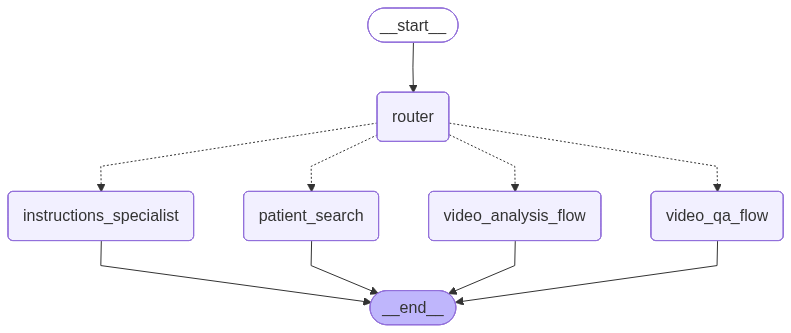

Patient: Maria S.
Profile: 34-year-old school teacher
Background: Lives with two children and works in a crowded classroom.
Chronic conditions: mild intermittent asthma
Current medications: albuterol inhaler as needed
Allergies: penicillin
Current context: Reports that several students at school have had fever and sore throat this week.


In [11]:
show_graph_structure(demo_graph_v3)
print(render_active_patient_context(ACTIVE_PATIENT))

## Structured specialist smoke test

If the control-model endpoint is offline, this cell still validates the notebook-local specialist prompt, the GGUF invocation path, and the strict JSON contract.

In [12]:
from video_pipeline.contracts import (
    VideoAnalysisResult, ExpressionResult, PoseResult, TranscriptionResult,
    DetectionWindow, DominantDetection, TranscriptSegment
)

mock_video_analysis = VideoAnalysisResult(
    video_id="mock_screening_001",
    duration_s=10.0,
    window_s=5.0,
    stride_s=2.5,
    expression=ExpressionResult(
        windows=[
            DetectionWindow(
                start_s=0.0,
                end_s=5.0,
                detections=[],
                dominant=DominantDetection(label="sad", score=0.85)
            ),
            DetectionWindow(
                start_s=5.0,
                end_s=10.0,
                detections=[],
                dominant=DominantDetection(label="neutral", score=0.90)
            )
        ]
    ),
    pose=PoseResult(
        windows=[
            DetectionWindow(
                start_s=0.0,
                end_s=5.0,
                detections=[],
                dominant=DominantDetection(label="hand_on_head", score=0.75)
            ),
            DetectionWindow(
                start_s=5.0,
                end_s=10.0,
                detections=[],
                dominant=DominantDetection(label="rounded_shoulders_or_asymmetry", score=0.80)
            )
        ]
    ),
    transcription=TranscriptionResult(
        language="pt",
        text="Estou sentindo muita dor de cabeça hoje. Parece que não consigo me concentrar.",
        segments=[
            TranscriptSegment(
                start_s=0.0,
                end_s=5.0,
                text="Estou sentindo muita dor de cabeça hoje."
            ),
            TranscriptSegment(
                start_s=5.0,
                end_s=10.0,
                text="Parece que não consigo me concentrar."
            )
        ],
        has_audio=True,
    )
)
print("Synthetic VideoAnalysisResult generated successfully.")

Synthetic VideoAnalysisResult generated successfully.


## Symptom flow demo

This cell runs one symptom-oriented request through the full graph and surfaces the final structured result plus the final control-model answer.

In [13]:
# qa_question = "Quais expressões e comportamentos foram observados no vídeo carregado e o que o paciente falou?"
# qa_result: NotebookState | None = None
# qa_failure: dict[str, str] | None = None

# try:
#     initial_state = create_initial_state(qa_question, ACTIVE_PATIENT_KEY)
#     initial_state["video_analysis_result"] = mock_video_analysis
    
#     qa_result = cast(
#         NotebookState,
#         demo_graph_v3.invoke(initial_state),
#     )
#     describe_run_result(qa_result)
# except Exception as error:
#     qa_failure = {
#         "question": qa_question,
#         "error_type": type(error).__name__,
#         "error": str(error),
#     }
#     qa_failure

## Instructions flow demo

This cell runs one instructions-oriented request through the graph and keeps the result in standard LangChain message history.

In [14]:
# instructions_question = "How should I describe my symptoms so this assistant can help me better?"
# instructions_result: NotebookState | None = None
# instructions_failure: dict[str, str] | None = None

# try:
#     instructions_result = cast(
#         NotebookState,
#         demo_graph_v3.invoke(create_initial_state(instructions_question, ACTIVE_PATIENT_KEY)),
#     )
#     describe_run_result(instructions_result)
# except Exception as error:
#     instructions_failure = {
#         "question": instructions_question,
#         "error_type": type(error).__name__,
#         "error": str(error),
#     }
#     instructions_failure

## Conversation history

The next cells print the final LangChain message history for each run using the built-in `pretty_print()` representation.

In [15]:
# if qa_result is None:
#     print("QA run did not complete; no history to display.")
# else:
#     for message in qa_result["messages"]:
#         message.pretty_print()

In [16]:
# if instructions_result is None:
#     print("Instructions run did not complete; no history to display.")
# else:
#     for message in instructions_result["messages"]:
#         message.pretty_print()

## Real video pipeline smoke test

This cell runs the repository `video_pipeline` against a local video and keeps the returned `VideoAnalysisResult` in memory as `real_video_analysis`.

For now, this does not change the LangGraph flow. The goal is only to verify that the real pipeline returns the same contract currently mocked by `mock_video_analysis`.

In [17]:
from IPython.display import JSON

REAL_VIDEO_PATH = Path("concepts_video/input_videos/abuse_with_audio.mp4")
REAL_PIPELINE_OUTPUT_DIR = Path("concepts_video/outputs/langgraph_router_real_pipeline")

real_video_analysis: VideoAnalysisResult | None = None
real_pipeline_failure: dict[str, str] | None = None

try:
    if not REAL_VIDEO_PATH.exists():
        raise FileNotFoundError(f"Video file not found: {REAL_VIDEO_PATH.resolve()}")

    real_pipeline_config = PipelineConfig(
        window_s=8.0,
        stride_s=5.0,
        debug=True,
        output_dir=str(REAL_PIPELINE_OUTPUT_DIR),
    )

    real_video_analysis = process_video(
        str(REAL_VIDEO_PATH),
        config=real_pipeline_config,
    )    

except Exception as error:
    real_pipeline_failure = {
        "video_path": str(REAL_VIDEO_PATH),
        "error_type": type(error).__name__,
        "error": str(error),
    }
    display(JSON(real_pipeline_failure))

100%|██████████| 1001/1001 [00:01<00:00, 779.35frames/s]


In [18]:
from IPython.display import Markdown

print(format_video_analysis_summary(real_video_analysis))
print(f"\nArtifacts written to: {REAL_PIPELINE_OUTPUT_DIR.resolve()}")

display(Markdown(
    "```json\n"
    + real_video_analysis.model_dump_json(indent=4)
    + "\n```"
))

Video Analysis Summary:
- Duration: 10.0s
- Transcript:
  [0.0s - 5.9s] Eu não sei mais o que fazer, ele me bate e diz que seu contar para alguém vai ser pior.
  [5.9s - 9.1s] Eu tenho medo, isso já acontece há muito tempo.
- Dominant Expressions:
  [0.0s - 8.0s] neutral_expression (score: 0.77)
  [5.0s - 10.0s] neutral_expression (score: 0.76)
- Posture Observations:
  [0.0s - 8.0s] hand_on_neck (score: 1.00)
  [5.0s - 10.0s] hand_on_neck (score: 1.00)

Artifacts written to: C:\Users\LuizAlbertodeAndrade\source\repos\screening_robot\concepts_video\outputs\langgraph_router_real_pipeline


```json
{
    "video_id": "abuse_with_audio",
    "duration_s": 10.0,
    "window_s": 8.0,
    "stride_s": 5.0,
    "expression": {
        "module": "expression",
        "windows": [
            {
                "start_s": 0.0,
                "end_s": 8.0,
                "detections": [
                    {
                        "label": "neutral_expression",
                        "score": 0.772,
                        "support": 0.513
                    },
                    {
                        "label": "sad_expression",
                        "score": 0.638,
                        "support": 0.301
                    },
                    {
                        "label": "fear_expression",
                        "score": 0.623,
                        "support": 0.119
                    },
                    {
                        "label": "surprise_expression",
                        "score": 0.783,
                        "support": 0.057
                    },
                    {
                        "label": "joy_expression",
                        "score": 0.734,
                        "support": 0.005
                    },
                    {
                        "label": "anger_expression",
                        "score": 0.325,
                        "support": 0.005
                    }
                ],
                "dominant": {
                    "label": "neutral_expression",
                    "score": 0.772
                }
            },
            {
                "start_s": 5.0,
                "end_s": 10.0,
                "detections": [
                    {
                        "label": "neutral_expression",
                        "score": 0.764,
                        "support": 0.45
                    },
                    {
                        "label": "sad_expression",
                        "score": 0.651,
                        "support": 0.392
                    },
                    {
                        "label": "fear_expression",
                        "score": 0.63,
                        "support": 0.1
                    },
                    {
                        "label": "surprise_expression",
                        "score": 0.788,
                        "support": 0.058
                    }
                ],
                "dominant": {
                    "label": "neutral_expression",
                    "score": 0.764
                }
            }
        ]
    },
    "pose": {
        "module": "pose",
        "windows": [
            {
                "start_s": 0.0,
                "end_s": 8.0,
                "detections": [
                    {
                        "label": "hand_on_neck",
                        "score": 1.0,
                        "support": 0.897
                    },
                    {
                        "label": "hand_on_chest",
                        "score": 1.0,
                        "support": 0.897
                    },
                    {
                        "label": "forward_head",
                        "score": 0.531,
                        "support": 1.0
                    }
                ],
                "dominant": {
                    "label": "hand_on_neck",
                    "score": 1.0
                }
            },
            {
                "start_s": 5.0,
                "end_s": 10.0,
                "detections": [
                    {
                        "label": "hand_on_neck",
                        "score": 1.0,
                        "support": 0.792
                    },
                    {
                        "label": "hand_on_chest",
                        "score": 1.0,
                        "support": 0.792
                    },
                    {
                        "label": "forward_head",
                        "score": 0.531,
                        "support": 1.0
                    }
                ],
                "dominant": {
                    "label": "hand_on_neck",
                    "score": 1.0
                }
            }
        ]
    },
    "transcription": {
        "module": "transcription",
        "language": "pt",
        "text": "Eu não sei mais o que fazer, ele me bate e diz que seu contar para alguém vai ser pior. Eu tenho medo, isso já acontece há muito tempo.",
        "segments": [
            {
                "start": 0.0,
                "end": 5.88,
                "text": "Eu não sei mais o que fazer, ele me bate e diz que seu contar para alguém vai ser pior."
            },
            {
                "start": 5.88,
                "end": 9.12,
                "text": "Eu tenho medo, isso já acontece há muito tempo."
            }
        ],
        "has_audio": true
    }
}
```

In [19]:
qa_question2 = "Analise o vídeo e apresente uma avaliação da paciente?"
qa_result2: NotebookState | None = None
qa_failure2: dict[str, str] | None = None

try:
    initial_state2 = create_initial_state(qa_question2, ACTIVE_PATIENT_KEY)
    initial_state2["video_analysis_result"] = real_video_analysis
    
    qa_result2 = cast(
        NotebookState,
        demo_graph_v3.invoke(initial_state2),
    )
    describe_run_result(qa_result2)
except Exception as error:
    qa_failure2 = {
        "question": qa_question2,
        "error_type": type(error).__name__,
        "error": str(error),
    }
    qa_failure2

Router response: destination='video_qa_flow' rationale='User wants an assessment based on video content, which falls under video QA.'


In [20]:
display(initial_state2)

{'messages': [HumanMessage(content='Analise o vídeo e apresente uma avaliação da paciente?', additional_kwargs={}, response_metadata={}, id='a0bc43d4-7832-454b-b2d5-e3005445dbf1')],
 'active_patient_key': 'maria_teacher',
 'active_patient_display_name': 'Maria S.',
 'active_patient_context': 'Patient: Maria S.\nProfile: 34-year-old school teacher\nBackground: Lives with two children and works in a crowded classroom.\nChronic conditions: mild intermittent asthma\nCurrent medications: albuterol inhaler as needed\nAllergies: penicillin\nCurrent context: Reports that several students at school have had fever and sore throat this week.',
 'route': None,
 'router_rationale': None,
 'video_path': None,
 'video_analysis_result': VideoAnalysisResult(video_id='abuse_with_audio', duration_s=10.0, window_s=8.0, stride_s=5.0, expression=ExpressionResult(module='expression', windows=[DetectionWindow(start_s=0.0, end_s=8.0, detections=[Detection(label='neutral_expression', score=0.772, support=0.513)

In [21]:
if qa_result2 is None:
    print("QA run did not complete; no history to display.")
else:
    for message in qa_result2["messages"]:
        message.pretty_print()

================================ Human Message =================================

Analise o vídeo e apresente uma avaliação da paciente?
================================== Ai Message ==================================

**Avaliação multimodal da paciente (vídeo de 10 s – “abuse_with_audio”)**

| Modalidade | Observações principais | Conexão com o discurso | Implicações clínicas |
|------------|------------------------|------------------------|----------------------|
| **Transcrição (fala)** | 1ª frase (0‑5.88 s): “Eu não sei mais o que fazer, ele me bate e diz que contar para alguém vai ser pior.”  <br>2ª frase (5.88‑9.12 s): “Eu tenho medo, isso já acontece há muito tempo.” | O paciente descreve violência doméstica, medo e sensação de impotência. | Indica risco de abuso físico e psicológico, potencial de transtorno de ansiedade, depressão e/ou PTSD. |
| **Expressões faciais** | • Dominante “neutral” (scores 0.772–0.764).  <br>• Expressões de “sad” (0.638–0.651) e “fear” (0.623–0.63) co

In [23]:
display(Markdown(qa_result2["messages"][-1].content))

**Avaliação multimodal da paciente (vídeo de 10 s – “abuse_with_audio”)**

| Modalidade | Observações principais | Conexão com o discurso | Implicações clínicas |
|------------|------------------------|------------------------|----------------------|
| **Transcrição (fala)** | 1ª frase (0‑5.88 s): “Eu não sei mais o que fazer, ele me bate e diz que contar para alguém vai ser pior.”  <br>2ª frase (5.88‑9.12 s): “Eu tenho medo, isso já acontece há muito tempo.” | O paciente descreve violência doméstica, medo e sensação de impotência. | Indica risco de abuso físico e psicológico, potencial de transtorno de ansiedade, depressão e/ou PTSD. |
| **Expressões faciais** | • Dominante “neutral” (scores 0.772–0.764).  <br>• Expressões de “sad” (0.638–0.651) e “fear” (0.623–0.63) com suporte moderado.  <br>• “Surprise” (0.783–0.788) aparece em ambos os intervalos, mas com suporte baixo. | A neutralidade dominante pode refletir tentativa de manter controle emocional diante de conteúdo traumático.  <br>As emoções de tristeza e medo acompanham o relato de violência e medo. | Pode indicar regulação emocional (apresentar “neutral” apesar de sentir tristeza e medo) – comum em vítimas de abuso.  <br>Presença de medo reforça a necessidade de avaliação de ansiedade e segurança. |
| **Postura / gestos** | • “hand_on_neck” e “hand_on_chest” com suporte >0.89 em 0‑8 s e >0.79 em 5‑10 s.  <br>• “forward_head” (score 0.531). | Gestos de auto‑proteção (mãos no pescoço e peito) e postura de alerta (cabeça ligeiramente para a frente). | Indica tensão física, autocontenção e possível retraimento.  <br>Podem ser respostas a ansiedade ou medo de repercussão física. |
| **Temporal** | • Nenhuma mudança significativa nas expressões faciais ou postura entre 0‑5.88 s e 5.88‑9.12 s.  <br>• O discurso, contudo, evolui de descrição de abuso para afirmação de medo e duração. | A consistência visual com a evolução verbal sugere que o estado emocional permanece estável, mas o foco do discurso muda para a percepção de risco. | O fato de não haver alívio visual pode indicar que a paciente não está experimentando alívio ou suporte no momento. |

---

### Síntese clínica (cautelosa)

1. **Indicadores de trauma e ansiedade**  
   - O discurso direto sobre agressão física e ameaça de retaliação (“contar vai ser pior”) combinado com expressões de medo e tristeza sugere sintomas de ansiedade e possivelmente de transtorno de estresse pós‑traumático.  
   - A postura de auto‑proteção (mãos no pescoço e peito) e a cabeça ligeiramente para a frente reforçam a percepção de ameaça contínua.

2. **Risco de violência doméstica**  
   - A narrativa indica abuso físico recorrente.  
   - A expressão “há muito tempo” sugere que o episódio não é isolado, aumentando a preocupação com risco de lesões graves ou de violência contínua.

3. **Impacto emocional**  
   - A neutralidade dominante pode ser um mecanismo de enfrentamento, mas a presença persistente de tristeza e medo indica que a paciente pode estar sofrendo depressão ou ansiedade.  
   - A falta de expressões de alegria ou relaxamento sugere ausência de bem‑estar emocional no momento.

4. **Considerações de saúde física**  
   - Não há evidências visíveis de sintomas respiratórios (ex.: falta de ar, tosse), o que é consistente com a condição de asma leve e que não parece estar exacerbada no vídeo.  
   - No entanto, o estresse crônico pode piorar a asma, e vale a pena avaliar a função pulmonar em consulta.

---

### O que pode merecer atenção adicional

| Item | Por que é relevante | Perguntas de seguimento |
|------|---------------------|--------------------------|
| **Avaliação de violência doméstica** | O relato descreve agressão física e ameaça de retaliação. | - Há testemunhas ou registros de ocorrências anteriores? <br> - A paciente tem acesso a um plano de segurança? |
| **Saúde mental (ansiedade, depressão, PTSD)** | Expressões de medo e tristeza, postura de alerta. | - Há histórico de ansiedade ou depressão? <br> - A paciente já buscou apoio psicológico? |
| **Risco de auto‑agressão ou suicídio** | Vítimas de abuso têm risco aumentado de ideação suicida. | - A paciente já pensou em se machucar ou em tirar a própria vida? <br> - Há suporte familiar ou de amigos? |
| **Função pulmonar** | Estresse crônico pode exacerbar asma. | - A paciente tem controle atual da asma? <br> - Há sintomas de falta de ar nos últimos dias? |

---

### Limitações da análise

1. **Duração curta** – apenas 10 s, sem contexto adicional (ambiente, outras pessoas).  
2. **Ausência de áudio qualidade** – não avaliamos tom de voz, pausas ou hesitações que poderiam enriquecer a interpretação.  
3. **Falta de dados de saúde mental pré‑existentes** – não sabemos se a paciente já tem diagnóstico de ansiedade ou depressão.  
4. **Modelo de detecção** – expressões e posturas são estimadas; podem haver erros de classificação.

---

### Recomendações de encaminhamento

1. **Consulta de saúde mental** – avaliação por psicólogo ou psiquiatra, com foco em trauma e ansiedade.  
2. **Avaliação de violência doméstica** – encaminhamento para serviços de apoio a vítimas (ouvidoria, abrigos, linha de apoio).  
3. **Plano de segurança** – discutir estratégias de proteção, contatos de emergência e possíveis medidas legais.  
4. **Reavaliação da asma** – monitorar sintomas respiratórios e ajustar medicação se necessário.  

---

**Resumo**  
A paciente Maria S. demonstra sinais visíveis de medo, tristeza e auto‑proteção enquanto descreve agressão física e ameaça de retaliação. Esses sinais multimodais são consistentes com risco de violência doméstica e com potenciais sintomas de ansiedade e trauma. Embora o vídeo não forneça diagnóstico definitivo, ele indica a necessidade de avaliação aprofundada de segurança, saúde mental e função pulmonar. O acompanhamento multidisciplinar, com foco em apoio psicológico e proteção, é recomendado.